The purpose of this file is to perform analysis on test_31-test60 (sample duration variance)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [20]:
durations = [90 + 30*i for i in range(18)]
n_sheets = 3

min_n_samples = np.inf
data = []
for duration in durations:
   sheet = pd.concat([pd.read_excel(f"new_variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(0,n_sheets)])
   # if duration > 300:
   #    sheet = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(0,n_sheets+1)])
   # else:
   #    sheet = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(0,n_sheets)])
   data.append(np.array([sheet[f"Channel {i}"] for i in range(3)]))
   print(f"There are {len(sheet)/5:3.0f} data points for {duration:3} s")
   min_n_samples = int(np.min([min_n_samples,len(sheet)/5]))
# There was an issue with test_39, so we can't convert to a numpy array (inhomogenous shape)
# data = np.array(data)
print(len(data))
for i in range(len(data)): print(len(data[i]),end=', ')
print()
for i in range(len(data[0])): print(len(data[0][i]),end=', ')
print()
for i in range(len(data[1])): print(len(data[1][i]),end=', ')

print(f"\n\nMinimum Number of Samples: {min_n_samples}")

There are 183 data points for  90 s
There are 145 data points for 120 s
There are 116 data points for 150 s
There are  97 data points for 180 s
There are  68 data points for 210 s
There are  73 data points for 240 s
There are  65 data points for 270 s
There are  59 data points for 300 s
There are  53 data points for 330 s
There are  49 data points for 360 s
There are  46 data points for 390 s
There are  43 data points for 420 s
There are  40 data points for 450 s
There are  37 data points for 480 s
There are  36 data points for 510 s
There are  33 data points for 540 s
There are  32 data points for 570 s
There are  30 data points for 600 s
18
3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 
915, 915, 915, 
725, 725, 725, 

Minimum Number of Samples: 30


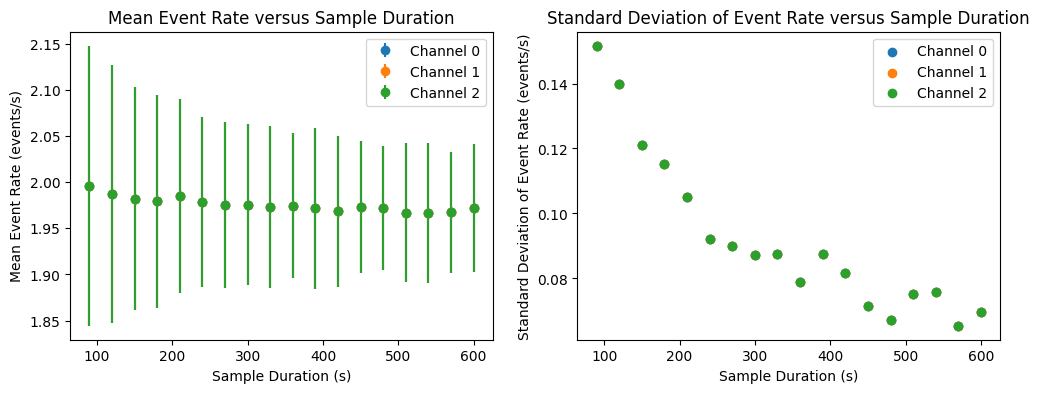

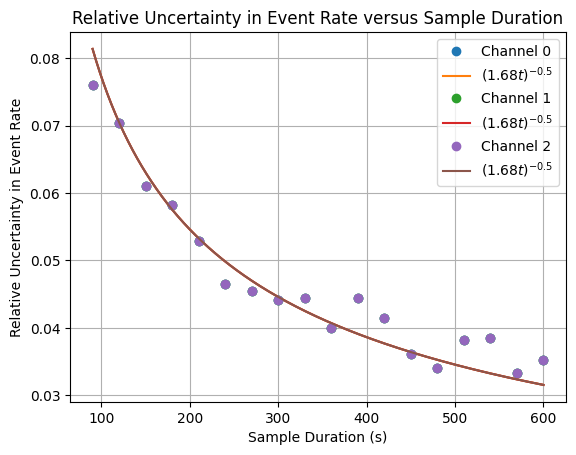

In [21]:
def get_mean_and_std(data, ch, idx, durations, pm = True):
   output = []
   for i in range(len(durations)):
      subset = data[i][ch][idx::5]
      # subset = subset[:min_n_samples]
      # print(subset)
      # print()
      if pm:
         subset = np.array([np.array(er.split(" ± "),dtype=np.float64)[0] for er in subset])
      # print(subset)
      # print()
      output.append([np.mean(subset),np.std(subset)])
   return output

def f(x,m,b):
   return m * x + b

def g(x,b):
   return 1 / np.sqrt(x * b)

fig, axs = plt.subplots(1,2,figsize=(12,4))
axs[1].set_title("Standard Deviation of Event Rate versus Sample Duration")
axs[1].set_xlabel("Sample Duration (s)")
axs[1].set_ylabel("Standard Deviation of Event Rate (events/s)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   axs[1].scatter(durations,[pair[1] for pair in event_rate],label=f"Channel {ch}")
axs[1].legend()

axs[0].set_title("Mean Event Rate versus Sample Duration")
axs[0].set_xlabel("Sample Duration (s)")
axs[0].set_ylabel("Mean Event Rate (events/s)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   axs[0].errorbar(durations,[pair[0] for pair in event_rate],yerr=[pair[1] for pair in event_rate],marker='o',linestyle='',label=f"Channel {ch}")
axs[0].legend()
plt.show()

x = np.linspace(np.min(durations),np.max(durations),1000)
plt.title("Relative Uncertainty in Event Rate versus Sample Duration")
plt.xlabel("Sample Duration (s)")
plt.ylabel("Relative Uncertainty in Event Rate")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in event_rate],p0=[1.99])
   plt.plot(durations,[pair[1]/pair[0] for pair in event_rate],marker='o',linestyle='',label=f"Channel {ch}")
   plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

In [22]:
langaus_data = []
for duration in durations:
   dur_data = []
   df = pd.concat([pd.read_excel(f"new_variance_results/{duration}s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets)])
   # if duration > 300:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets+1)])
   # else:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   i=0
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['landau_x_mpv'], ch['landau_xi'], ch['gauss_sigma'], ch['0.10% Threshold']])
      dur_data.append(ch_stats)
   langaus_data.append(dur_data)

print(len(langaus_data))
print(len(langaus_data[0]))
print(len(langaus_data[0][0]))
print(len(langaus_data[0][0][0]))
print(langaus_data[0][0][0])

18
4
5
183
[0.96591162 1.09203771 4.16674499 2.74280929 2.14364999 2.73777571
 3.36955668 4.62070446 4.06499748 2.47060196 3.25185659 4.42854598
 1.86062837 3.39757389 4.88536051 3.77201171 2.55227332 2.29430123
 3.06652584 2.44934055 3.33543024 4.93630775 2.27990636 3.64993071
 3.6906536  1.49904273 2.05829566 2.68031817 3.13865633 2.74937528
 1.66055711 3.92857524 3.92300969 2.92267503 1.15697137 3.22644936
 0.71578682 0.98003107 2.33232567 2.71335319 2.60987707 2.0315686
 2.38868564 2.2898451  1.99728378 1.32643178 1.39787694 2.53003463
 1.50939264 1.65430028 1.79859093 2.91903192 3.44079378 1.53978727
 2.72416738 2.54057073 4.96062728 2.19923635 2.58865508 1.86922936
 1.06623469 1.65814143 2.58520922 2.46549075 3.26364097 2.8240938
 1.24084163 4.32941335 2.29873316 4.89630525 0.83358761 2.63271937
 3.3020126  3.30027468 2.22235193 7.70239598 2.27697411 2.94139029
 1.43676876 3.91133575 3.31500462 4.44670561 1.69091476 1.80265591
 1.81564942 1.79477358 2.63196987 1.35485912 3.725465

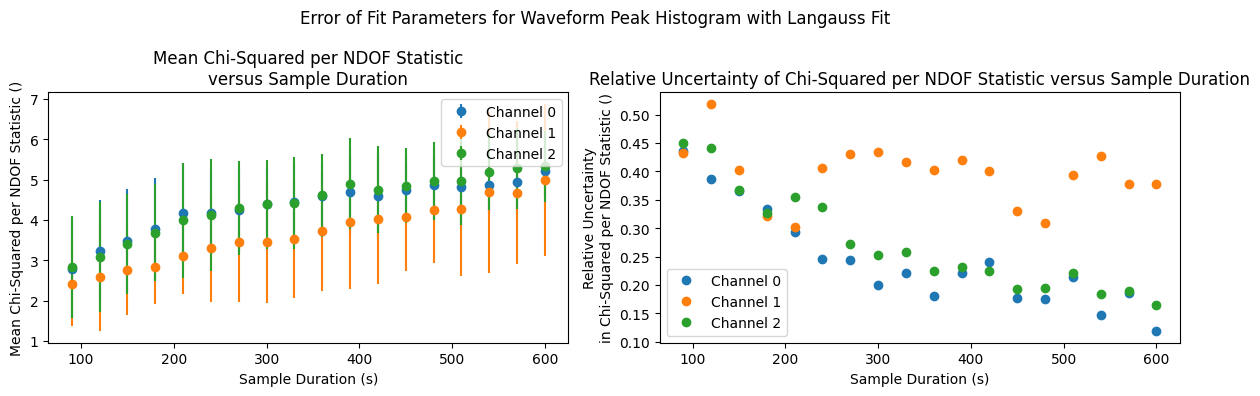

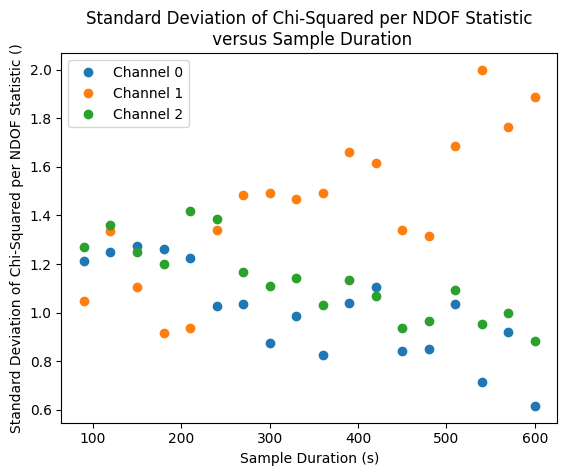

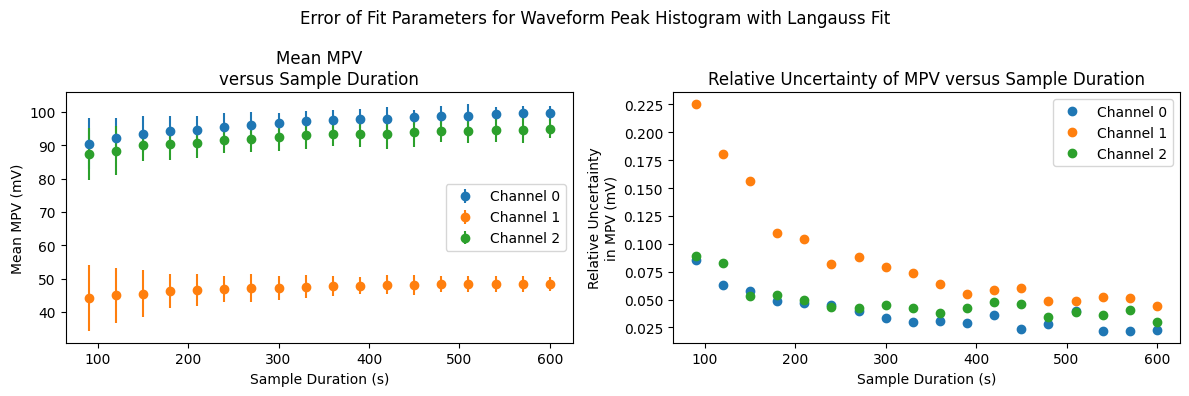

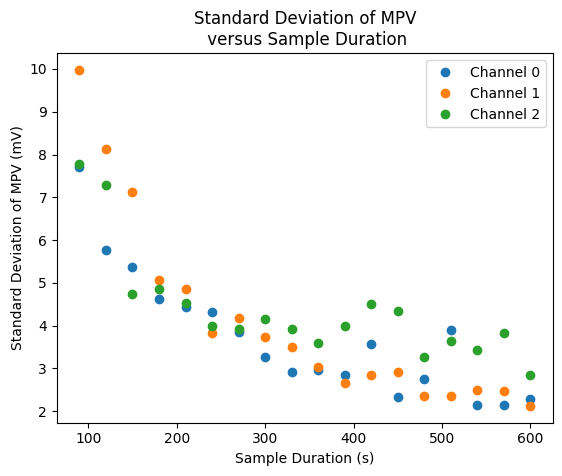

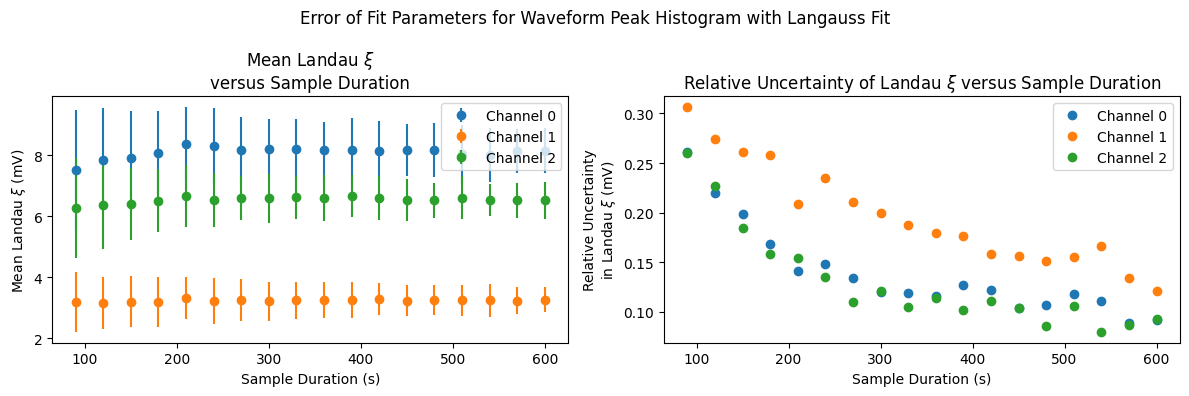

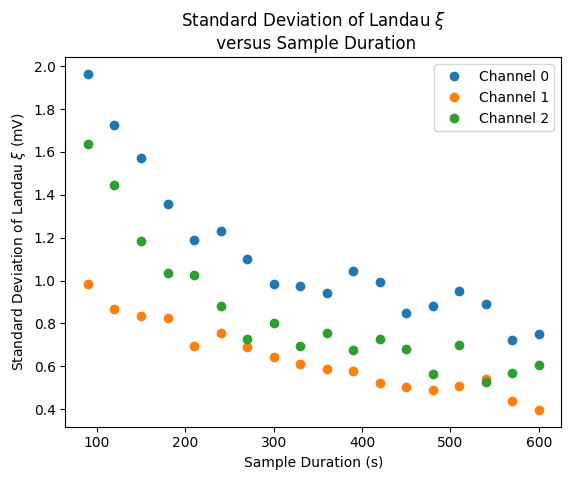

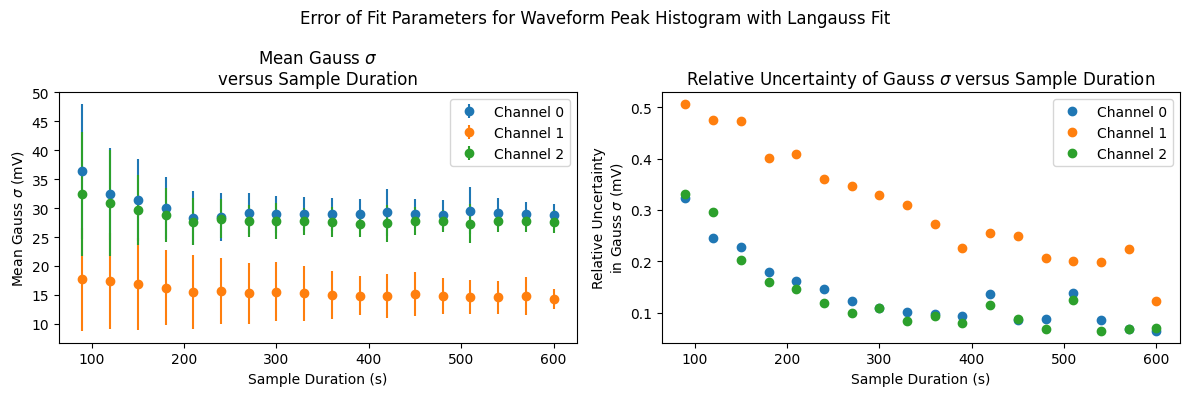

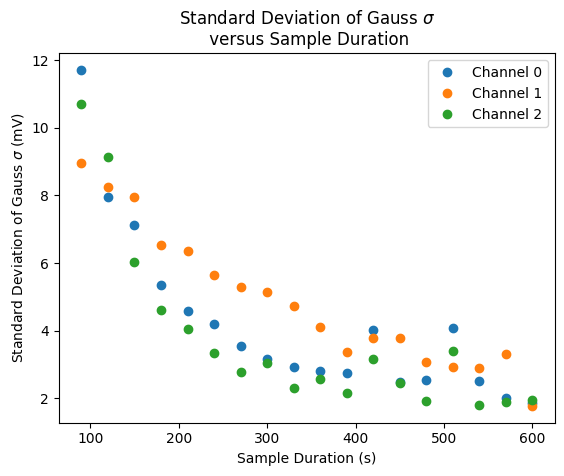

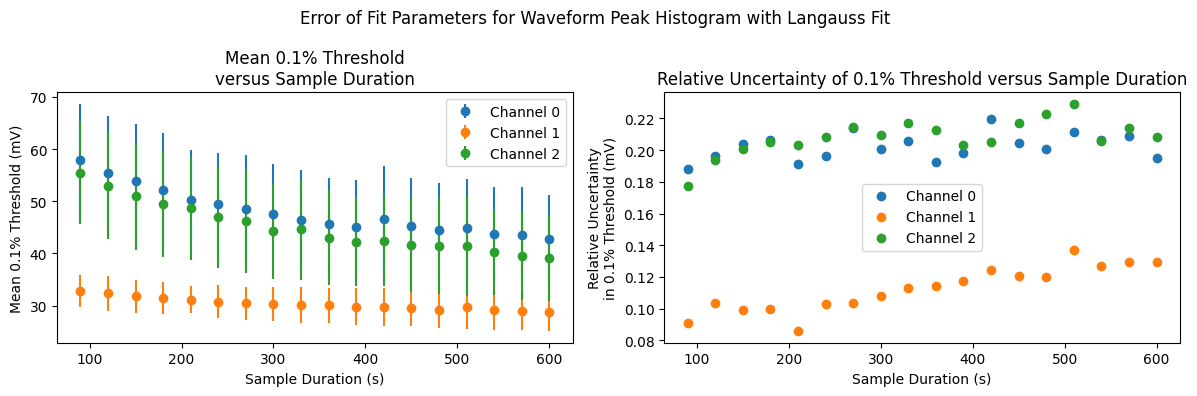

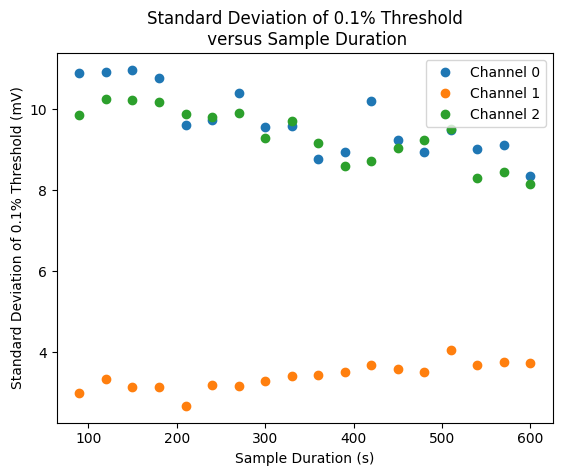

In [23]:
# def get_mean_and_std2(data, ch, idx, durations, pm = True):
#    output = []
#    for i in range(len(durations)):
#       subset = data[i][ch][idx]
#       output.append([np.mean(subset),np.std(subset)])
#    return output

def get_mean_and_std2(data, ch, idx, durations, pm=True):
   output = []
   for i in range(len(durations)):
      subset = data[i][ch][idx]
      # subset = subset[:min_n_samples]
      
      # # The Print Trap
      # if np.std(subset) > 0.5: 
      #     print(f"WARNING: High STD at duration {durations[i]}, channel {ch}")
      #     print(f"Data in subset: {subset}\\n")

      # # Looking for Outliers
      # dict = {'data': subset}
      # df = pd.DataFrame(dict)
      # q1 = df['data'].quantile(0.25)
      # q3 = df['data'].quantile(0.75)
      # iqr = q3-q1
      # lower_bound = q1 - 1.5 * iqr
      # upper_bound = q3 + 1.5 * iqr
      # outliers = df[(df['data'] < lower_bound) | (df['data'] > upper_bound)]
      # if len(outliers) != 0:
      #    print(f"Outliers identified for {durations[i]}, channel {ch}:")
      #    print(outliers)
      #    print(f"Mean: {np.mean(subset)}")
          
      output.append([np.mean(subset), np.std(subset)])
   return output

stats = ['Chi-Squared per NDOF Statistic', 'MPV', r'Landau $\xi$', r'Gauss $\sigma$','0.1% Threshold']
units = ['', 'mV', 'mV', 'mV', 'mV']
p0_f=[1.2,-0.0004]
p0_g=[2,]

for j in range(len(stats)):
   fig, axs = plt.subplots(1,2,figsize=(12,4))
   fig.suptitle("Error of Fit Parameters for Waveform Peak Histogram with Langauss Fit")
   axs[1].set_title(f"Relative Uncertainty of {stats[j]} versus Sample Duration")
   # axs[1].set_title(f"Relative Uncertainty of {stats[j]}\n ({min_n_samples} Samples) versus Sample Duration")
   axs[1].set_xlabel("Sample Duration (s)")
   axs[1].set_ylabel("Relative Uncertainty\nin "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      axs[1].plot(durations,[pair[1]/pair[0] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
      prev_colour = axs[1].lines[-1].get_color()
      # popt_f,pcov_f = curve_fit(f,durations,[pair[1]/pair[0] for pair in info],p0=p0_f)
      # plt.plot(x,f(x, *popt_f),label=f"({popt_f[0]:.2e}$~t+{popt_f[1]:.2f}$",color=prev_colour)
      # popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in info],p0=p0_g)
      # plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$",color=prev_colour)
   axs[1].legend()

   axs[0].set_title("Mean "+ stats[j] + "\nversus Sample Duration")
   axs[0].set_xlabel("Sample Duration (s)")
   axs[0].set_ylabel("Mean "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      axs[0].errorbar(durations,[pair[0] for pair in info],yerr=[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   axs[0].legend()
   plt.tight_layout()
   plt.show()

   plt.title(f"Standard Deviation of {stats[j]}\n versus Sample Duration")
   # plt.title(f"Standard Deviation of {stats[j]}\n ({min_n_samples} Samples) versus Sample Duration")
   plt.xlabel("Sample Duration (s)")
   plt.ylabel("Standard Deviation of " + stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      plt.plot(durations,[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   plt.legend()
   plt.show()




In [24]:
energy_data = []
for duration in durations:
   dur_data = []
   df = pd.concat([pd.read_excel(f"new_variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets)])
   # if duration > 300:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets+1)])
   # else:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   i=0
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['K'], ch['mean'], ch['std']])
      dur_data.append(ch_stats)
   energy_data.append(dur_data)

print(len(energy_data))
print(len(energy_data[0]))
print(len(energy_data[0][0]))
print(len(energy_data[0][0][0]))
print(energy_data[0][0][0])

18
4
4
183
[8.42598543e-01 1.25546512e+00 1.02638950e+01 1.59205384e+00
 7.94960484e-01 4.23011399e-01 3.57703295e+00 2.14004711e+00
 5.85508907e-01 8.49634225e-01 1.99935633e+00 2.20310459e+00
 6.98015305e-01 6.08060779e-01 3.00322863e+02 6.45435283e-01
 1.17183830e+00 6.70171762e-01 1.07680220e+00 1.63622710e+00
 6.38511408e-01 1.05383725e+02 9.44275035e-01 2.27799395e+00
 8.07816598e-01 9.43762318e-01 1.27253077e+00 1.97932286e+00
 1.14897276e+00 1.65343864e+00 6.78673430e-01 9.67375586e-01
 2.11712657e+00 5.35128248e-01 2.32208447e+00 1.75682081e+00
 1.10260229e+00 4.05136108e-01 8.47567570e-01 6.36282268e-01
 1.11025785e+00 6.38665334e-01 1.40838949e+00 1.28197199e+00
 1.07611138e+00 1.67733835e+00 6.03031741e-01 1.05449466e+00
 1.54395013e+00 1.34050393e+00 1.23035349e+00 9.46728207e-01
 8.95672292e-01 4.00445225e-01 1.01889614e+00 3.25993017e+00
 2.46324542e+00 7.88971568e-01 1.17153200e+00 9.13082837e-01
 6.98224143e-01 4.69506612e-01 7.46063982e-01 1.70744556e+00
 1.89582562e+

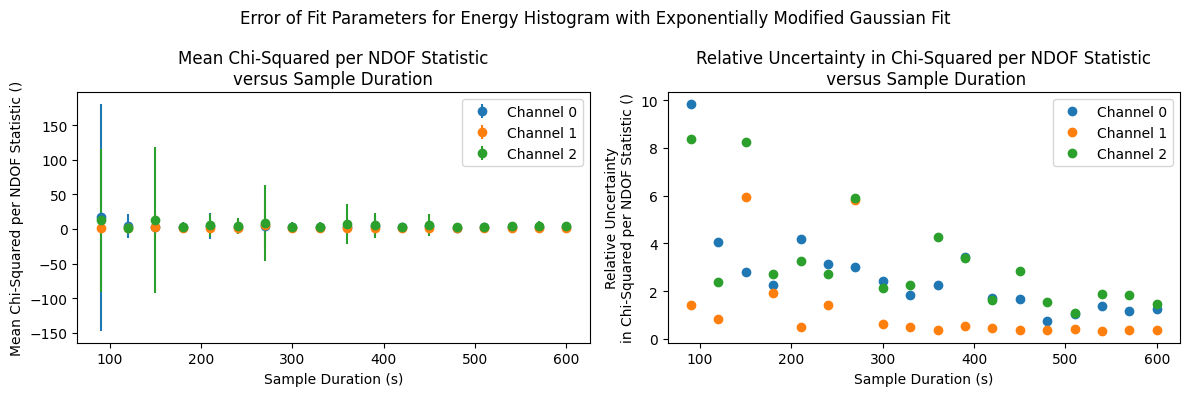

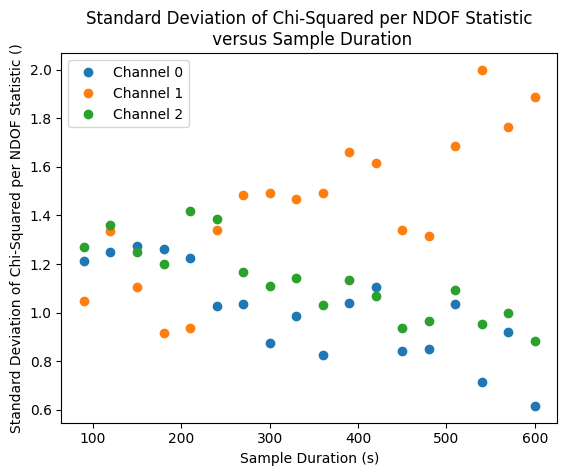

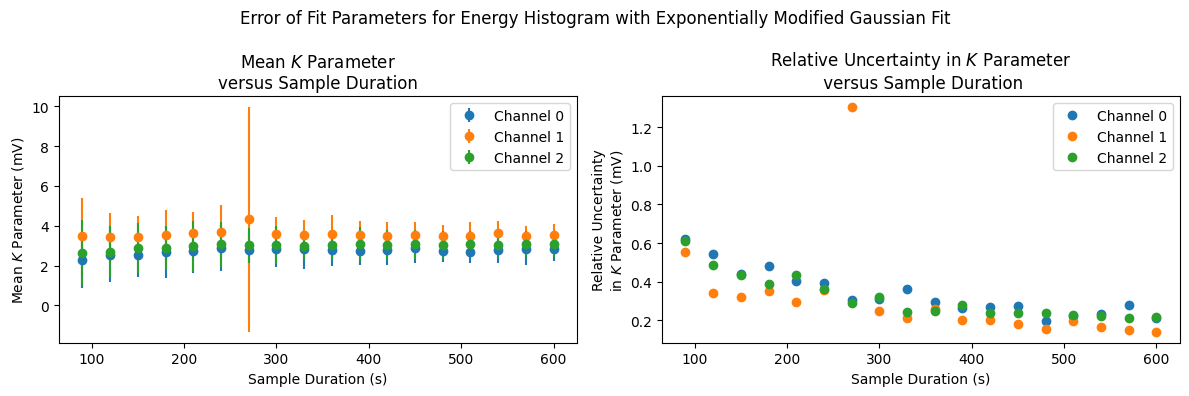

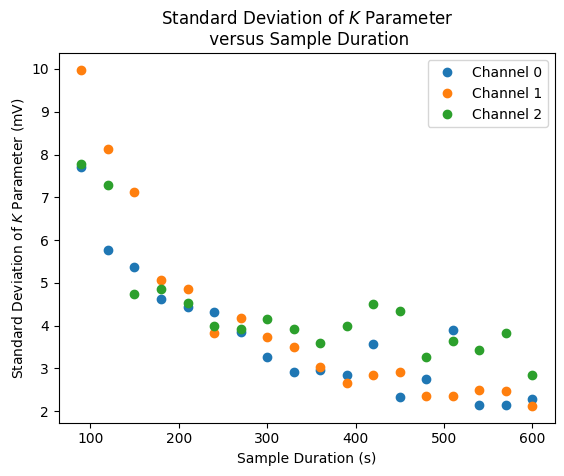

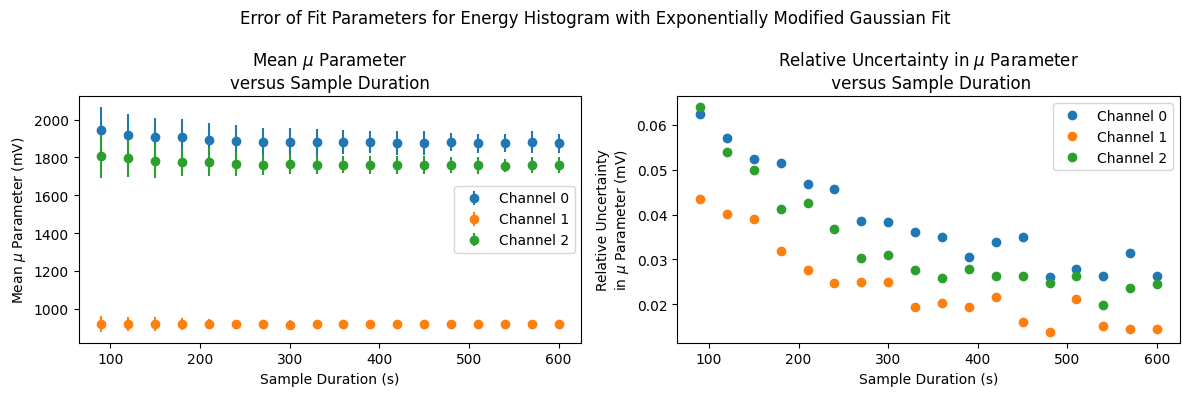

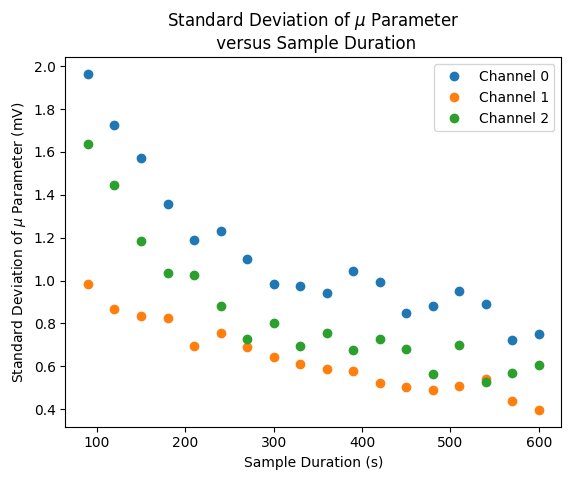

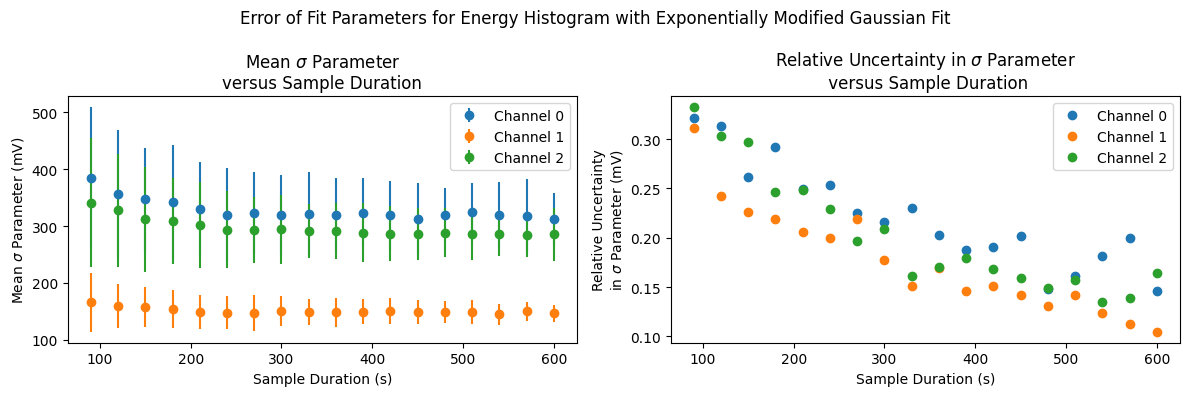

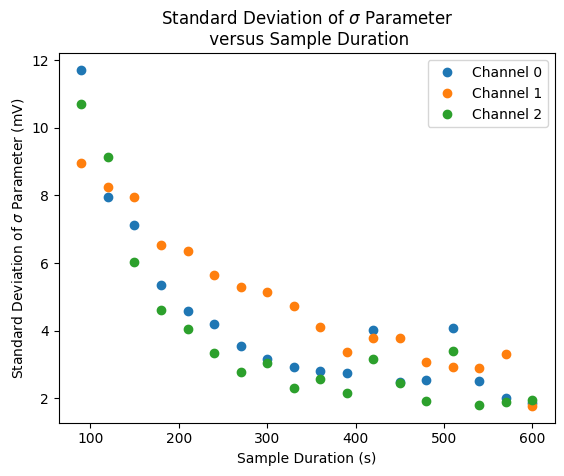

In [25]:
stats = ['Chi-Squared per NDOF Statistic', '$K$ Parameter', r'$\mu$ Parameter', r'$\sigma$ Parameter']
units = ['', 'mV', 'mV', 'mV']
for j in range(len(stats)):
   fig, axs = plt.subplots(1,2,figsize=(12,4))
   fig.suptitle("Error of Fit Parameters for Energy Histogram with Exponentially Modified Gaussian Fit")
   axs[1].set_title(f"Relative Uncertainty in {stats[j]}\n versus Sample Duration")
   # axs[1].set_title(f"Relative Uncertainty in {stats[j]}\n ({min_n_samples} Samples) versus Sample Duration")
   axs[1].set_xlabel("Sample Duration (s)")
   axs[1].set_ylabel("Relative Uncertainty\nin " + stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(energy_data,ch,j,durations)
      axs[1].plot(durations,[pair[1]/pair[0] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
      # prev_colour = axs[1].lines[-1].get_color()
      # popt_f,pcov_f = curve_fit(f,durations,[pair[1]/pair[0] for pair in info],p0=p0_f)
      # plt.plot(x,f(x, *popt_f),label=f"({popt_f[0]:.2e}$~t+{popt_f[1]:.2f}$",color=prev_colour)
      # popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in info],p0=p0_g)
      # plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$",color=prev_colour)
   axs[1].legend()

   axs[0].set_title("Mean "+ stats[j] + "\nversus Sample Duration")
   axs[0].set_xlabel("Sample Duration (s)")
   axs[0].set_ylabel("Mean "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(energy_data,ch,j,durations)
      axs[0].errorbar(durations,[pair[0] for pair in info],yerr=[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   axs[0].legend()
   plt.tight_layout()
   plt.show()

   plt.title(f"Standard Deviation of {stats[j]}\n versus Sample Duration")
   # plt.title(f"Standard Deviation of {stats[j]}\n ({min_n_samples} Samples) versus Sample Duration")
   plt.xlabel("Sample Duration (s)")
   plt.ylabel("Standard Deviation of " + stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      plt.plot(durations,[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   plt.legend()
   plt.show()

Goal: Create a histogram showing the distribution of my parameters for each channel individually

Indexing format: duration, channel, parameter

7


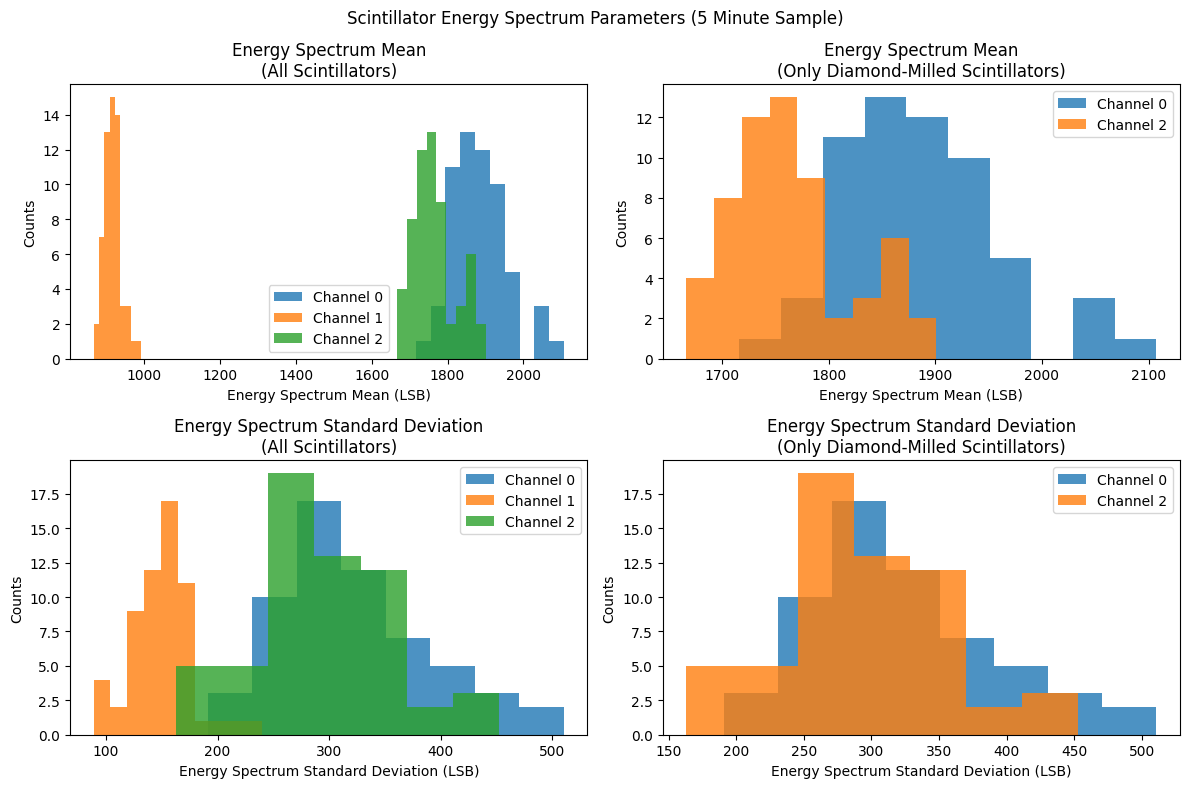

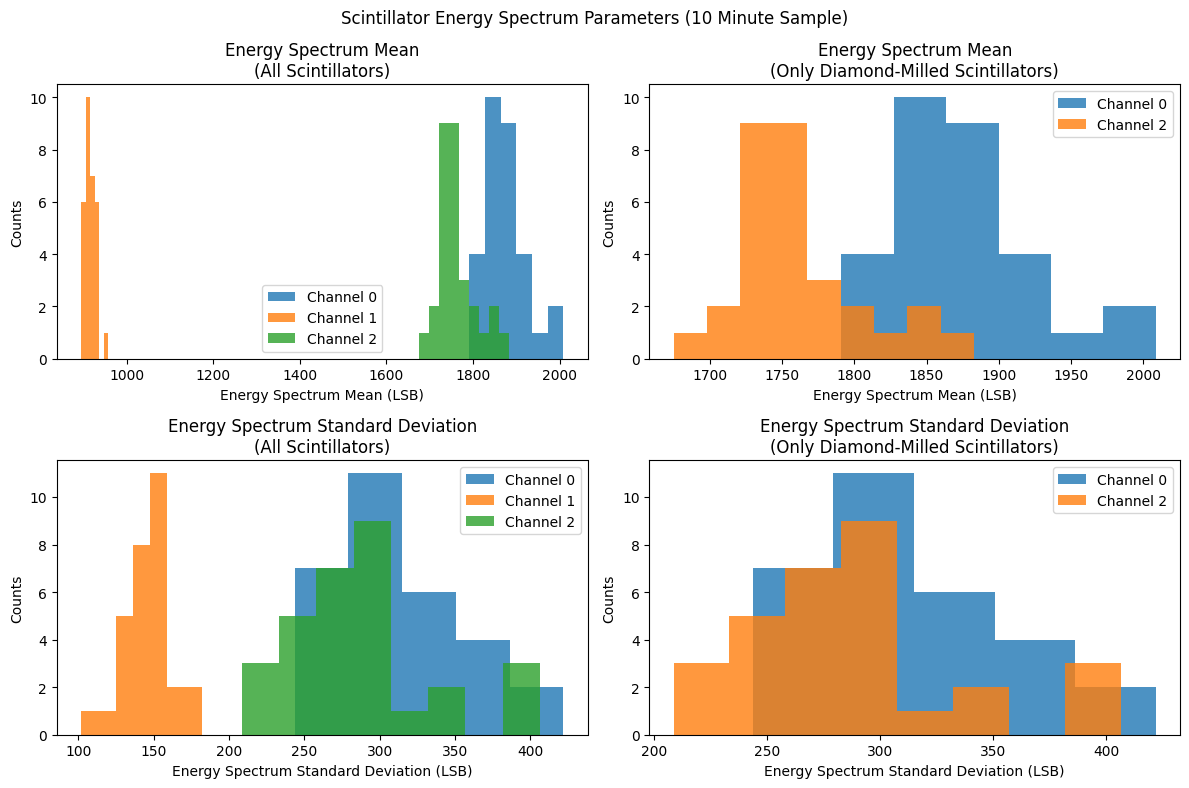

In [26]:
index_5min, index_10min = int((300-90)/30), int((600-90)/30)
print(index_5min)

fig, axs = plt.subplots(2,2,figsize=(12,8))
fig.suptitle("Scintillator Energy Spectrum Parameters (5 Minute Sample)")
axs[0,0].set_title(f"Energy Spectrum Mean\n(All Scintillators)")
axs[0,1].set_title(f"Energy Spectrum Mean\n(Only Diamond-Milled Scintillators)")
axs[0,0].set_xlabel("Energy Spectrum Mean (LSB)")
axs[0,1].set_xlabel("Energy Spectrum Mean (LSB)")
axs[0,0].set_ylabel("Counts")
axs[0,1].set_ylabel("Counts")
axs[1,0].set_title(f"Energy Spectrum Standard Deviation\n(All Scintillators)")
axs[1,1].set_title(f"Energy Spectrum Standard Deviation\n(Only Diamond-Milled Scintillators)")
axs[1,0].set_xlabel("Energy Spectrum Standard Deviation (LSB)")
axs[1,1].set_xlabel("Energy Spectrum Standard Deviation (LSB)")
axs[1,0].set_ylabel("Counts")
axs[1,1].set_ylabel("Counts")
for ch in range(3):
   axs[0,0].hist(energy_data[index_5min][ch][2],label=f"Channel {ch}",alpha=0.8,bins='fd')
   axs[1,0].hist(energy_data[index_5min][ch][3],label=f"Channel {ch}",alpha=0.8,bins='fd')
   if ch!=1:
      axs[0,1].hist(energy_data[index_5min][ch][2],label=f"Channel {ch}",alpha=0.8,bins='fd')
      axs[1,1].hist(energy_data[index_5min][ch][3],label=f"Channel {ch}",alpha=0.8,bins='fd')
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2,2,figsize=(12,8))
fig.suptitle("Scintillator Energy Spectrum Parameters (10 Minute Sample)")
axs[0,0].set_title(f"Energy Spectrum Mean\n(All Scintillators)")
axs[0,1].set_title(f"Energy Spectrum Mean\n(Only Diamond-Milled Scintillators)")
axs[0,0].set_xlabel("Energy Spectrum Mean (LSB)")
axs[0,1].set_xlabel("Energy Spectrum Mean (LSB)")
axs[0,0].set_ylabel("Counts")
axs[0,1].set_ylabel("Counts")
axs[1,0].set_title(f"Energy Spectrum Standard Deviation\n(All Scintillators)")
axs[1,1].set_title(f"Energy Spectrum Standard Deviation\n(Only Diamond-Milled Scintillators)")
axs[1,0].set_xlabel("Energy Spectrum Standard Deviation (LSB)")
axs[1,1].set_xlabel("Energy Spectrum Standard Deviation (LSB)")
axs[1,0].set_ylabel("Counts")
axs[1,1].set_ylabel("Counts")
for ch in range(3):
   axs[0,0].hist(energy_data[index_10min][ch][2],label=f"Channel {ch}",alpha=0.8,bins='fd')
   axs[1,0].hist(energy_data[index_10min][ch][3],label=f"Channel {ch}",alpha=0.8,bins='fd')
   if ch!=1:
      axs[0,1].hist(energy_data[index_10min][ch][2],label=f"Channel {ch}",alpha=0.8,bins='fd')
      axs[1,1].hist(energy_data[index_10min][ch][3],label=f"Channel {ch}",alpha=0.8,bins='fd')
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
plt.tight_layout()
plt.show()

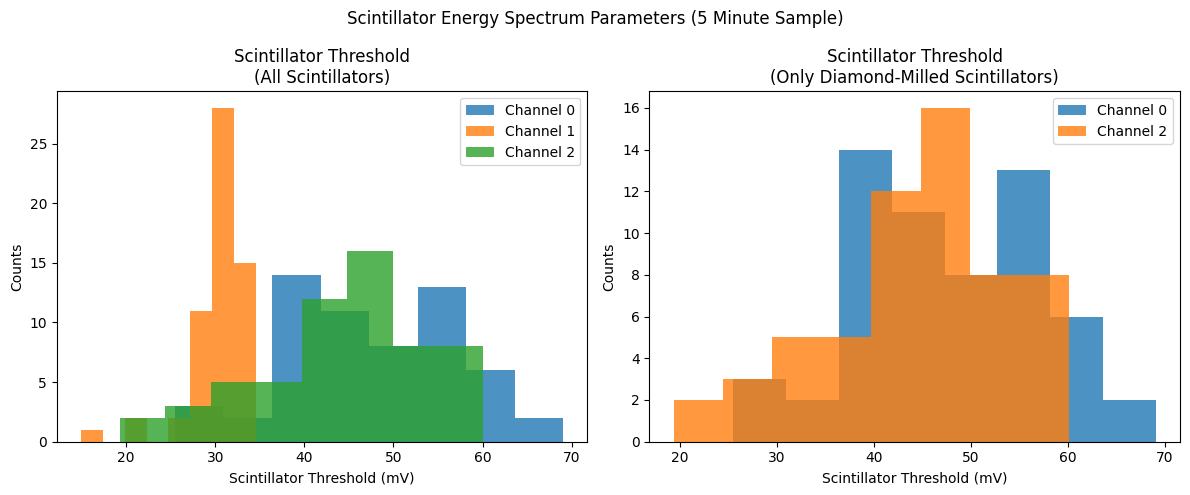

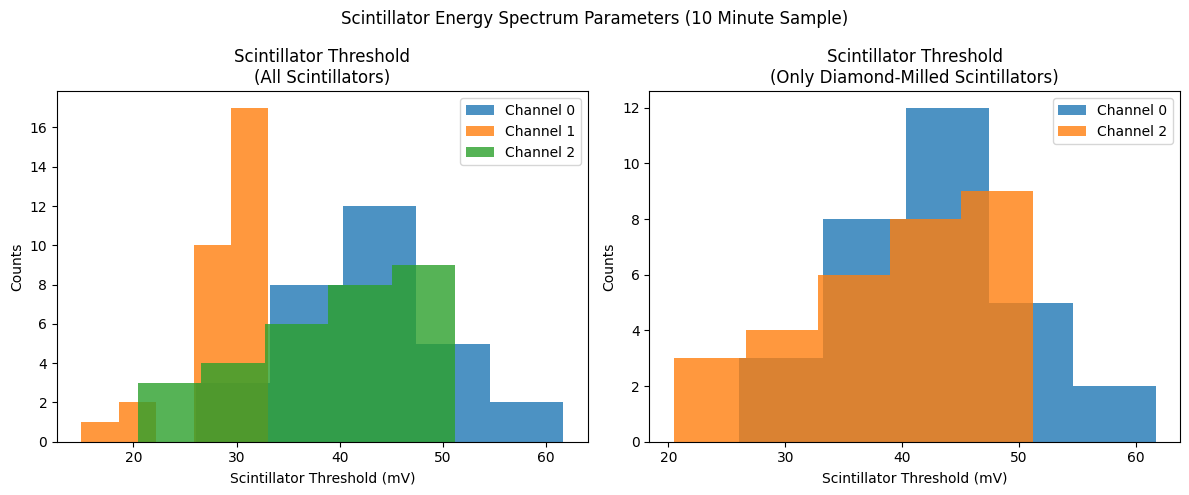

In [27]:
fig, axs = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Scintillator Energy Spectrum Parameters (5 Minute Sample)")
axs[0].set_title(f"Scintillator Threshold\n(All Scintillators)")
axs[1].set_title(f"Scintillator Threshold\n(Only Diamond-Milled Scintillators)")
axs[0].set_xlabel("Scintillator Threshold (mV)")
axs[1].set_xlabel("Scintillator Threshold (mV)")
axs[0].set_ylabel("Counts")
axs[1].set_ylabel("Counts")
for ch in range(3):
   axs[0].hist(langaus_data[index_5min][ch][4],label=f"Channel {ch}",alpha=0.8,bins=round(np.sqrt(len(langaus_data[index_5min][ch][4]))))
   if ch!=1:
      axs[1].hist(langaus_data[index_5min][ch][4],label=f"Channel {ch}",alpha=0.8,bins=round(np.sqrt(len(langaus_data[index_5min][ch][4]))))
axs[0].legend()
axs[1].legend()
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Scintillator Energy Spectrum Parameters (10 Minute Sample)")
axs[0].set_title(f"Scintillator Threshold\n(All Scintillators)")
axs[1].set_title(f"Scintillator Threshold\n(Only Diamond-Milled Scintillators)")
axs[0].set_xlabel("Scintillator Threshold (mV)")
axs[1].set_xlabel("Scintillator Threshold (mV)")
axs[0].set_ylabel("Counts")
axs[1].set_ylabel("Counts")
for ch in range(3):
   axs[0].hist(langaus_data[index_10min][ch][4],label=f"Channel {ch}",alpha=0.8,bins=round(np.sqrt(len(langaus_data[index_10min][ch][4]))))
   if ch!=1:
      axs[1].hist(langaus_data[index_10min][ch][4],label=f"Channel {ch}",alpha=0.8,bins=round(np.sqrt(len(langaus_data[index_10min][ch][4]))))
axs[0].legend()
axs[1].legend()
plt.tight_layout()
plt.show()

Goal: Make Energy Distribution Mean vs Scintillator Threshold Plot

59
59


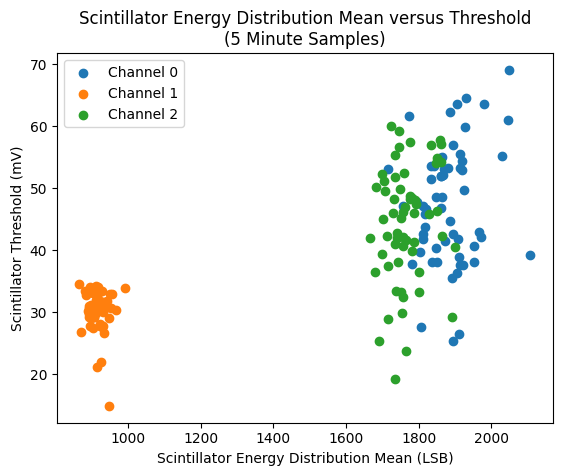

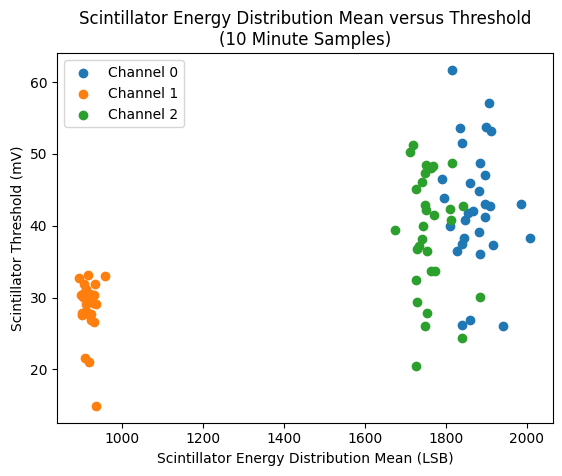

In [28]:
print(len(energy_data[index_5min][0][2]))
print(len(langaus_data[index_5min][0][4]))

plt.title("Scintillator Energy Distribution Mean versus Threshold\n(5 Minute Samples)")
plt.xlabel("Scintillator Energy Distribution Mean (LSB)")
plt.ylabel("Scintillator Threshold (mV)")
for ch in range(3):
   plt.scatter(energy_data[index_5min][ch][2],langaus_data[index_5min][ch][4],label=f"Channel {ch}")
plt.legend()
plt.show()

plt.title("Scintillator Energy Distribution Mean versus Threshold\n(10 Minute Samples)")
plt.xlabel("Scintillator Energy Distribution Mean (LSB)")
plt.ylabel("Scintillator Threshold (mV)")
for ch in range(3):
   plt.scatter(energy_data[index_10min][ch][2],langaus_data[index_10min][ch][4],label=f"Channel {ch}")
plt.legend()
plt.show()

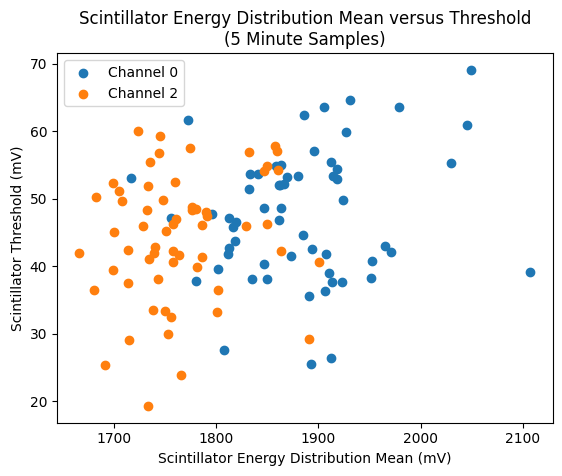

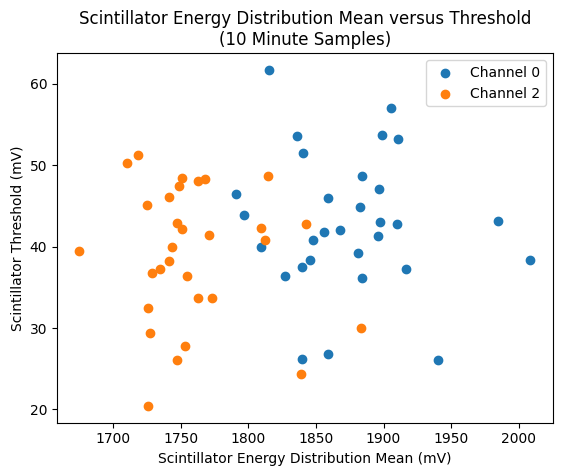

In [29]:
plt.title("Scintillator Energy Distribution Mean versus Threshold\n(5 Minute Samples)")
plt.xlabel("Scintillator Energy Distribution Mean (mV)")
plt.ylabel("Scintillator Threshold (mV)")
for ch in range(3):
   if ch!=1:
      plt.scatter(energy_data[index_5min][ch][2],langaus_data[index_5min][ch][4],label=f"Channel {ch}")
plt.legend()
plt.show()

plt.title("Scintillator Energy Distribution Mean versus Threshold\n(10 Minute Samples)")
plt.xlabel("Scintillator Energy Distribution Mean (mV)")
plt.ylabel("Scintillator Threshold (mV)")
for ch in range(3):
   if ch!=1:
      plt.scatter(energy_data[index_10min][ch][2],langaus_data[index_10min][ch][4],label=f"Channel {ch}")
plt.legend()
plt.show()

(236,)
[24, 48, 72, 96, 118, 140, 162, 184, 197, 210, 223]
[24, 48, 72, 96, 118, 140, 162, 184, 197, 210, 223]


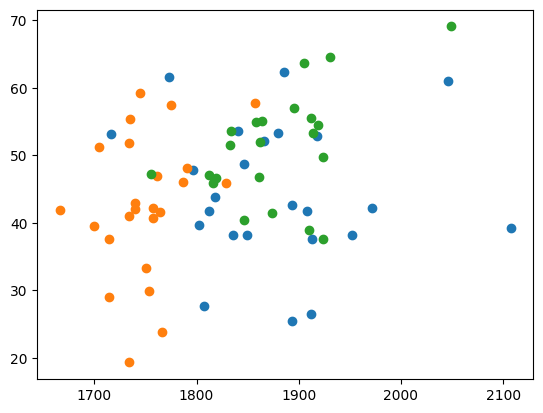

In [30]:
thresh_5 = pd.concat([pd.read_excel(f"new_variance_results/300s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets)])
Emean_5 = pd.concat([pd.read_excel(f"new_variance_results/300s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets)])
thresh_10 = pd.concat([pd.read_excel(f"new_variance_results/600s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets)])
Emean_10 = pd.concat([pd.read_excel(f"new_variance_results/600s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets)])

# print(thresh_5['0.10% Threshold'])
# print(Emean_5['mean'])
print(thresh_5['Channel'].shape)
# print(Emean_5['Channel'])

def find_channel_switches(data):
   data = data['Channel']
   channel_indices = []
   prev = data.iloc[0]
   for i in range(len(data)):
      if data.iloc[i] != prev:
         channel_indices.append(i)
      prev = data.iloc[i]
   return channel_indices

print(find_channel_switches(thresh_5))
print(find_channel_switches(Emean_5))
ch_idx = find_channel_switches(thresh_5)

plt.scatter(Emean_5['mean'].iloc[ch_idx[0]:ch_idx[1]],thresh_5['0.10% Threshold'].iloc[ch_idx[0]:ch_idx[1]])
plt.scatter(Emean_5['mean'].iloc[ch_idx[2]:ch_idx[3]],thresh_5['0.10% Threshold'].iloc[ch_idx[2]:ch_idx[3]])
plt.scatter(Emean_5['mean'].iloc[ch_idx[4]:ch_idx[5]],thresh_5['0.10% Threshold'].iloc[ch_idx[4]:ch_idx[5]])

   # df = df.sort_values(by='Channel',kind='mergesort')
   # grouped = [group for _, group in df.groupby('Channel')]
   # i=0
   # for ch in grouped:
   #    ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['landau_x_mpv'], ch['landau_xi'], ch['gauss_sigma'], ch['0.10% Threshold']])
   #    dur_data.append(ch_stats)
   # langaus_data.append(dur_data)

I think that the reason I don't get some kind of linear trend is because everything is out of order so I'm not actually able to directly compare the same events.

I want to do this now just for the energy distribution parameters with improved ECG

In [31]:
ECG_energy_data = []
df = pd.concat([pd.read_excel(f"ECG_variance_results/600s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(77,79)])
df = df.sort_values(by='Channel',kind='mergesort')
grouped = [group for _, group in df.groupby('Channel')]
i=0
for ch in grouped:
   ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['K'], ch['mean'], ch['std']])
   ECG_energy_data.append(ch_stats)

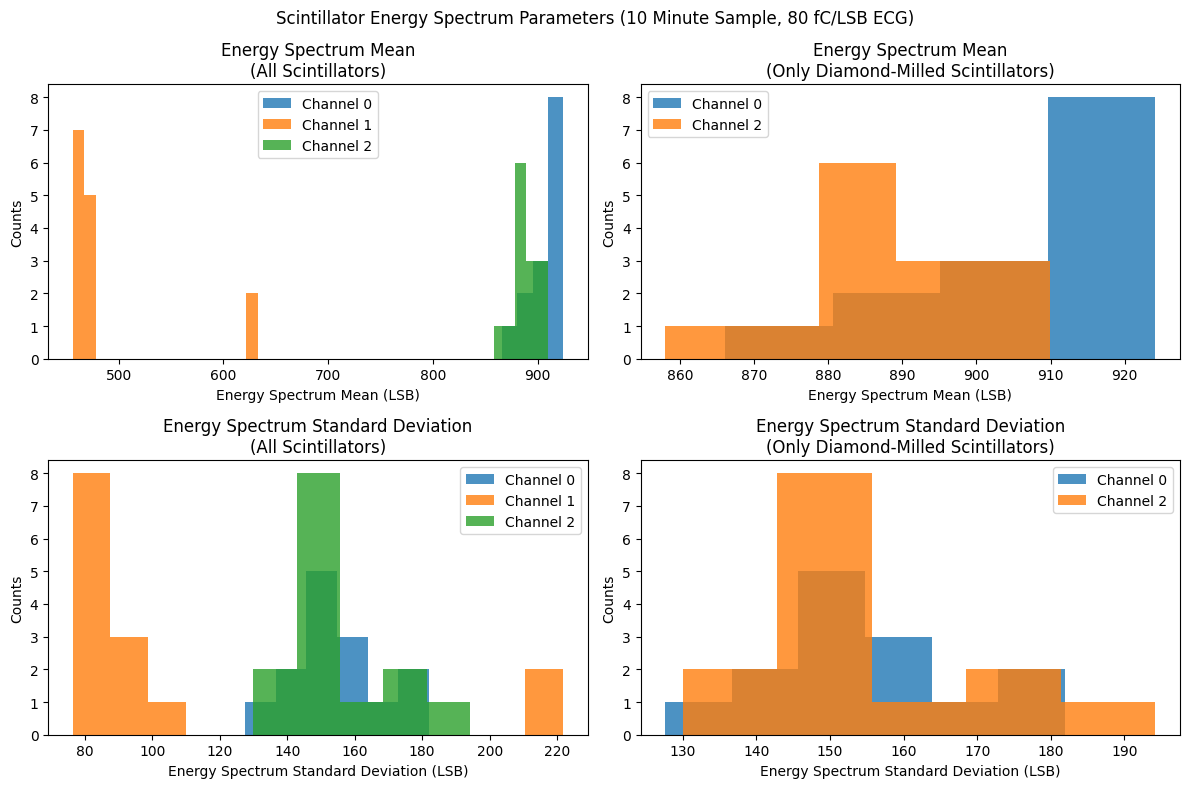

In [32]:
fig, axs = plt.subplots(2,2,figsize=(12,8))
fig.suptitle("Scintillator Energy Spectrum Parameters (10 Minute Sample, 80 fC/LSB ECG)")
axs[0,0].set_title(f"Energy Spectrum Mean\n(All Scintillators)")
axs[0,1].set_title(f"Energy Spectrum Mean\n(Only Diamond-Milled Scintillators)")
axs[0,0].set_xlabel("Energy Spectrum Mean (LSB)")
axs[0,1].set_xlabel("Energy Spectrum Mean (LSB)")
axs[0,0].set_ylabel("Counts")
axs[0,1].set_ylabel("Counts")
axs[1,0].set_title(f"Energy Spectrum Standard Deviation\n(All Scintillators)")
axs[1,1].set_title(f"Energy Spectrum Standard Deviation\n(Only Diamond-Milled Scintillators)")
axs[1,0].set_xlabel("Energy Spectrum Standard Deviation (LSB)")
axs[1,1].set_xlabel("Energy Spectrum Standard Deviation (LSB)")
axs[1,0].set_ylabel("Counts")
axs[1,1].set_ylabel("Counts")
for ch in range(3):
   axs[0,0].hist(ECG_energy_data[ch][2],label=f"Channel {ch}",alpha=0.8,bins='fd')
   axs[1,0].hist(ECG_energy_data[ch][3],label=f"Channel {ch}",alpha=0.8,bins='fd')
   if ch!=1:
      axs[0,1].hist(ECG_energy_data[ch][2],label=f"Channel {ch}",alpha=0.8,bins='fd')
      axs[1,1].hist(ECG_energy_data[ch][3],label=f"Channel {ch}",alpha=0.8,bins='fd')
axs[0,0].legend()
axs[0,1].legend()
axs[1,0].legend()
axs[1,1].legend()
plt.tight_layout()
plt.show()

In [41]:
for ch in range(3):
   print(f"===== Channel {ch} =====")
   mean_mu, std_mu = np.mean(ECG_energy_data[ch][2]), np.std(ECG_energy_data[ch][2])
   old_mean_mu, old_std_mu = np.mean(energy_data[index_10min][ch][2]), np.std(energy_data[index_10min][ch][2])
   print(f"The average energy distribution mean is {mean_mu:.2f} ± {std_mu:.2f}.")
   print(f"=> {std_mu/mean_mu*100:.2f}% (80 fC/LSB) relative error versus {old_std_mu/old_mean_mu*100:.2f}% (40 fC/LSB)")

   mean_sigma, std_sigma = np.mean(ECG_energy_data[ch][3]), np.std(ECG_energy_data[ch][3])
   old_mean_sigma, old_std_sigma = np.mean(energy_data[index_10min][ch][3]), np.std(energy_data[index_10min][ch][3])
   print(f"The average energy distribution standard deviation is {mean_sigma:.2f} ± {std_sigma:.2f}.")
   print(f"=> {std_sigma/mean_sigma*100:.2f}% (80 fC/LSB) relative error versus {old_std_sigma/old_mean_sigma*100:.2f}% (40 fC/LSB)")

===== Channel 0 =====
The average energy distribution mean is 906.74 ± 16.62.
=> 1.83% (80 fC/LSB) relative error versus 2.63% (40 fC/LSB)
The average energy distribution standard deviation is 155.62 ± 14.15.
=> 9.09% (80 fC/LSB) relative error versus 14.58% (40 fC/LSB)
===== Channel 1 =====
The average energy distribution mean is 489.05 ± 57.06.
=> 11.67% (80 fC/LSB) relative error versus 1.45% (40 fC/LSB)
The average energy distribution standard deviation is 103.61 ± 48.15.
=> 46.48% (80 fC/LSB) relative error versus 10.50% (40 fC/LSB)
===== Channel 2 =====
The average energy distribution mean is 888.21 ± 12.92.
=> 1.45% (80 fC/LSB) relative error versus 2.46% (40 fC/LSB)
The average energy distribution standard deviation is 153.35 ± 15.95.
=> 10.40% (80 fC/LSB) relative error versus 16.41% (40 fC/LSB)
